# WIP: Find a way to make it possible to read in provedIt data and have an existing model make predictions?

In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
!pwd

/Users/amarmesic/Documents/tudelft/thesis/DNANet


In [3]:
from DNAnet.data.data_models import Panel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import NFIFileCategorizer
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard
from DNAnet.evaluation.visualizations import plot_profile


from typing import List
from pathlib import Path

# Create HID Image

In [4]:
ppf6_panel_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/SGPanel_PPF6C_SPOOR.xml"
hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/2p_5p_Dataset_NFI/Raw data .HID files"

In [5]:
# get all the HID files from the hid_files_path directory
def find_files_by_suffix(root_dir, suffix) -> List[Path]:
    """
    Recursively find all files in root_dir that end with the given suffix.
    """
    return list(Path(root_dir).rglob(f'*{suffix}'))


In [6]:
panel = Panel(ppf6_panel_path)
hid_files = find_files_by_suffix(hid_files_path, ".hid")
file_categorizer = NFIFileCategorizer()
sample_validator = NFIValidationStrategy()

In [7]:
images = CustomHIDDataset(
    limit=100,
    files=hid_files,
    panel=panel,
    size_standard=InternalSizeStandard.WEN_ILS.value,
    file_categorization_strategy=file_categorizer,
    sample_validation_strategy=sample_validator,
)

In [8]:
len(images)

100

In [9]:
from config_io import load_model

unet_model = load_model("config/models/unet.yaml")
unet_model.load("resources/model/current_best_unet/")
predictions = unet_model.predict_batch(images[:30])

/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-07 10:14:21 INFO     Calling alleles from predicted segmentation...


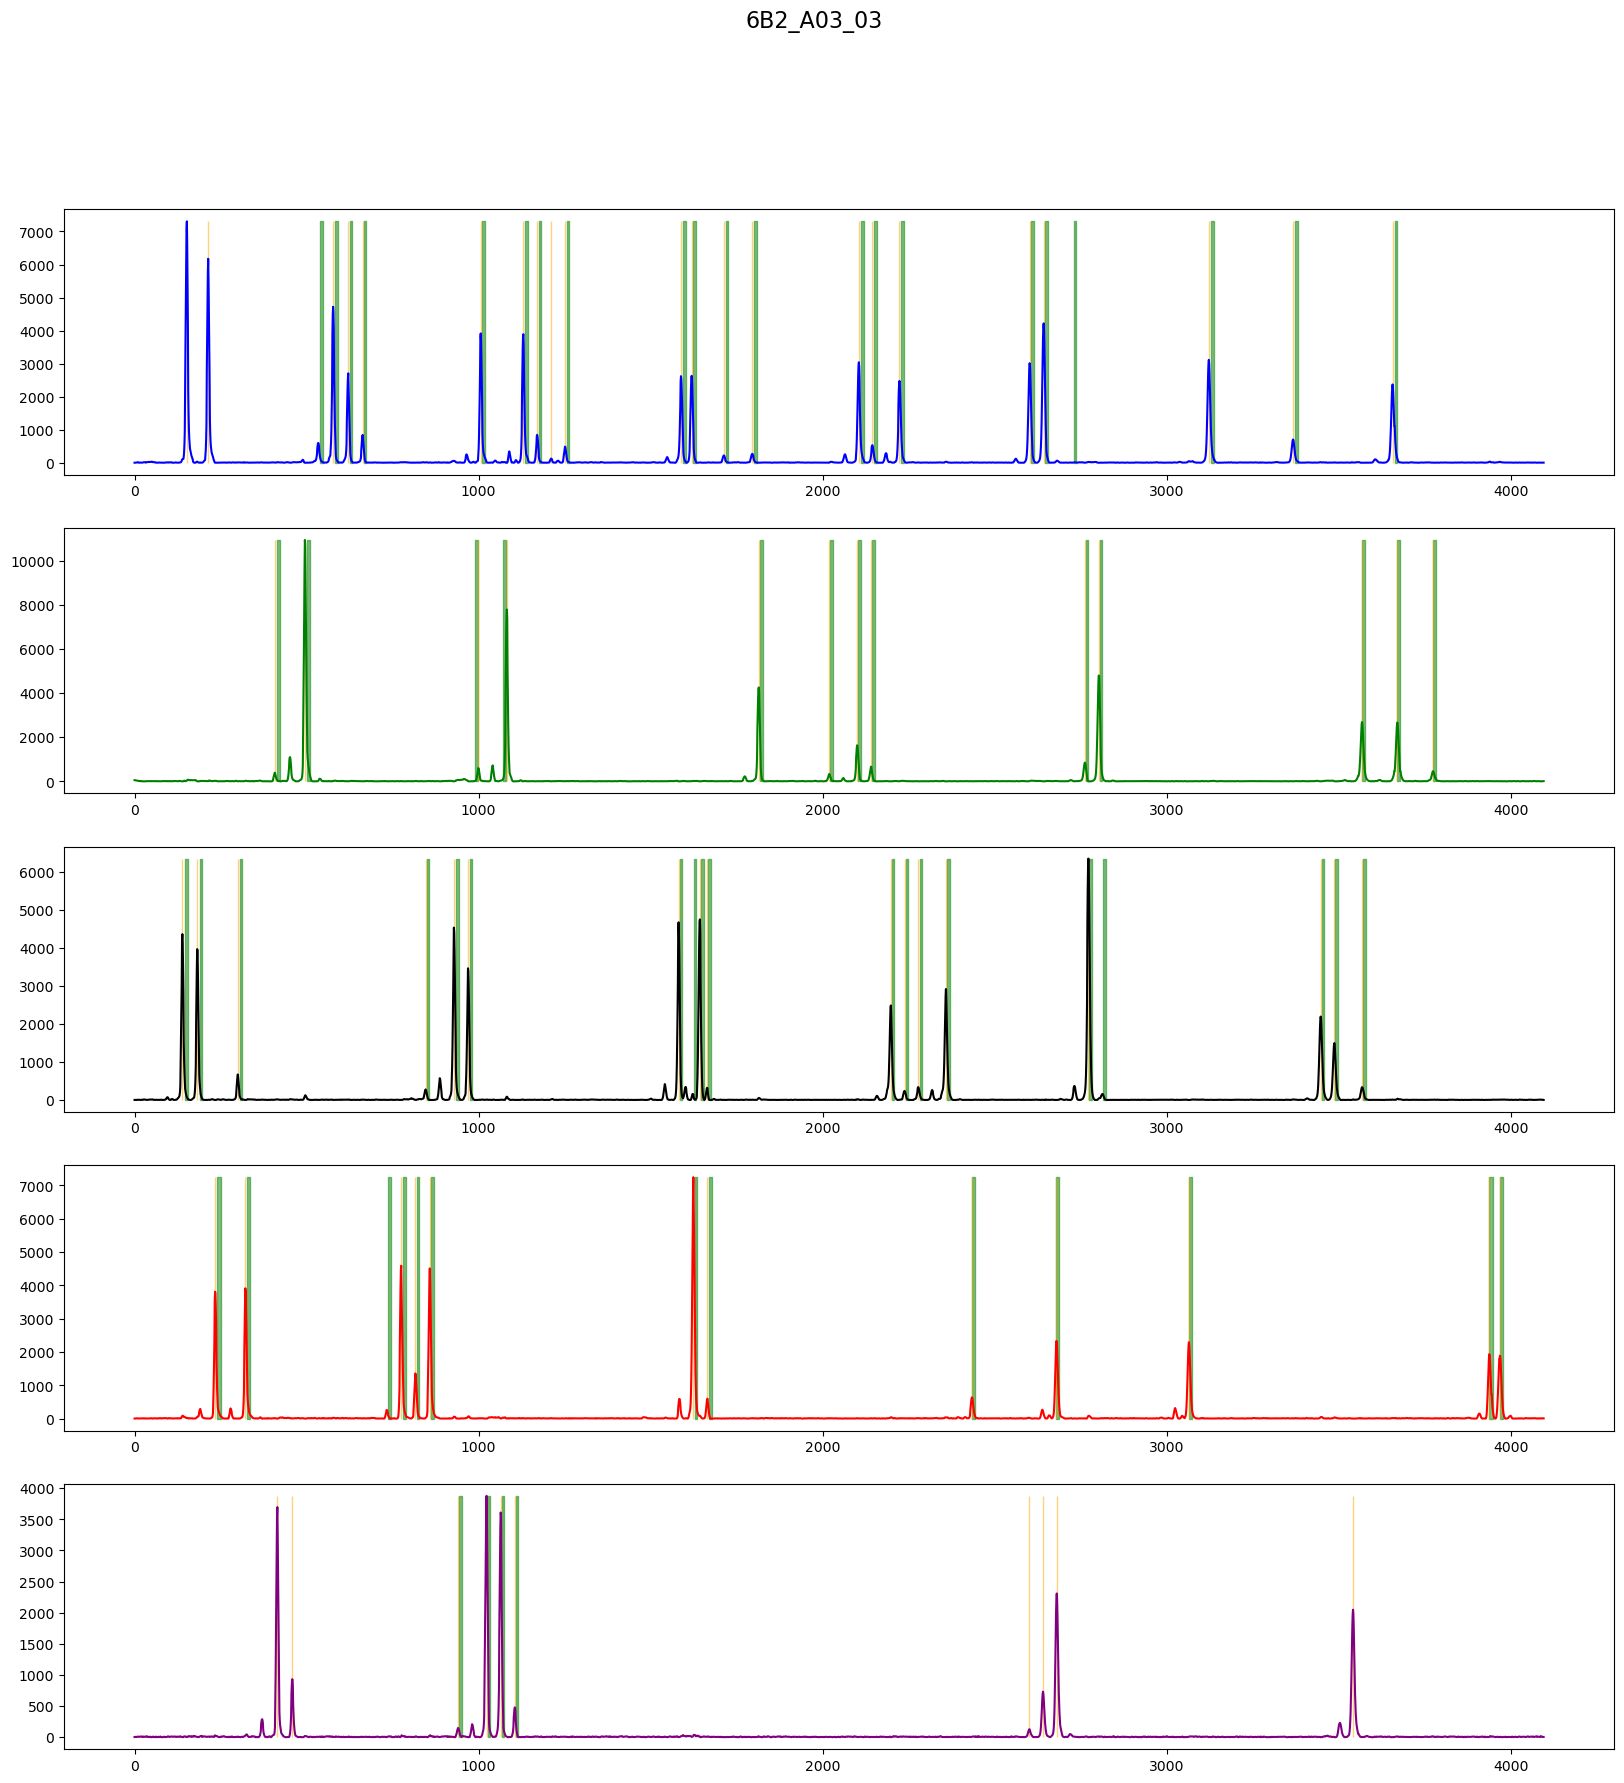

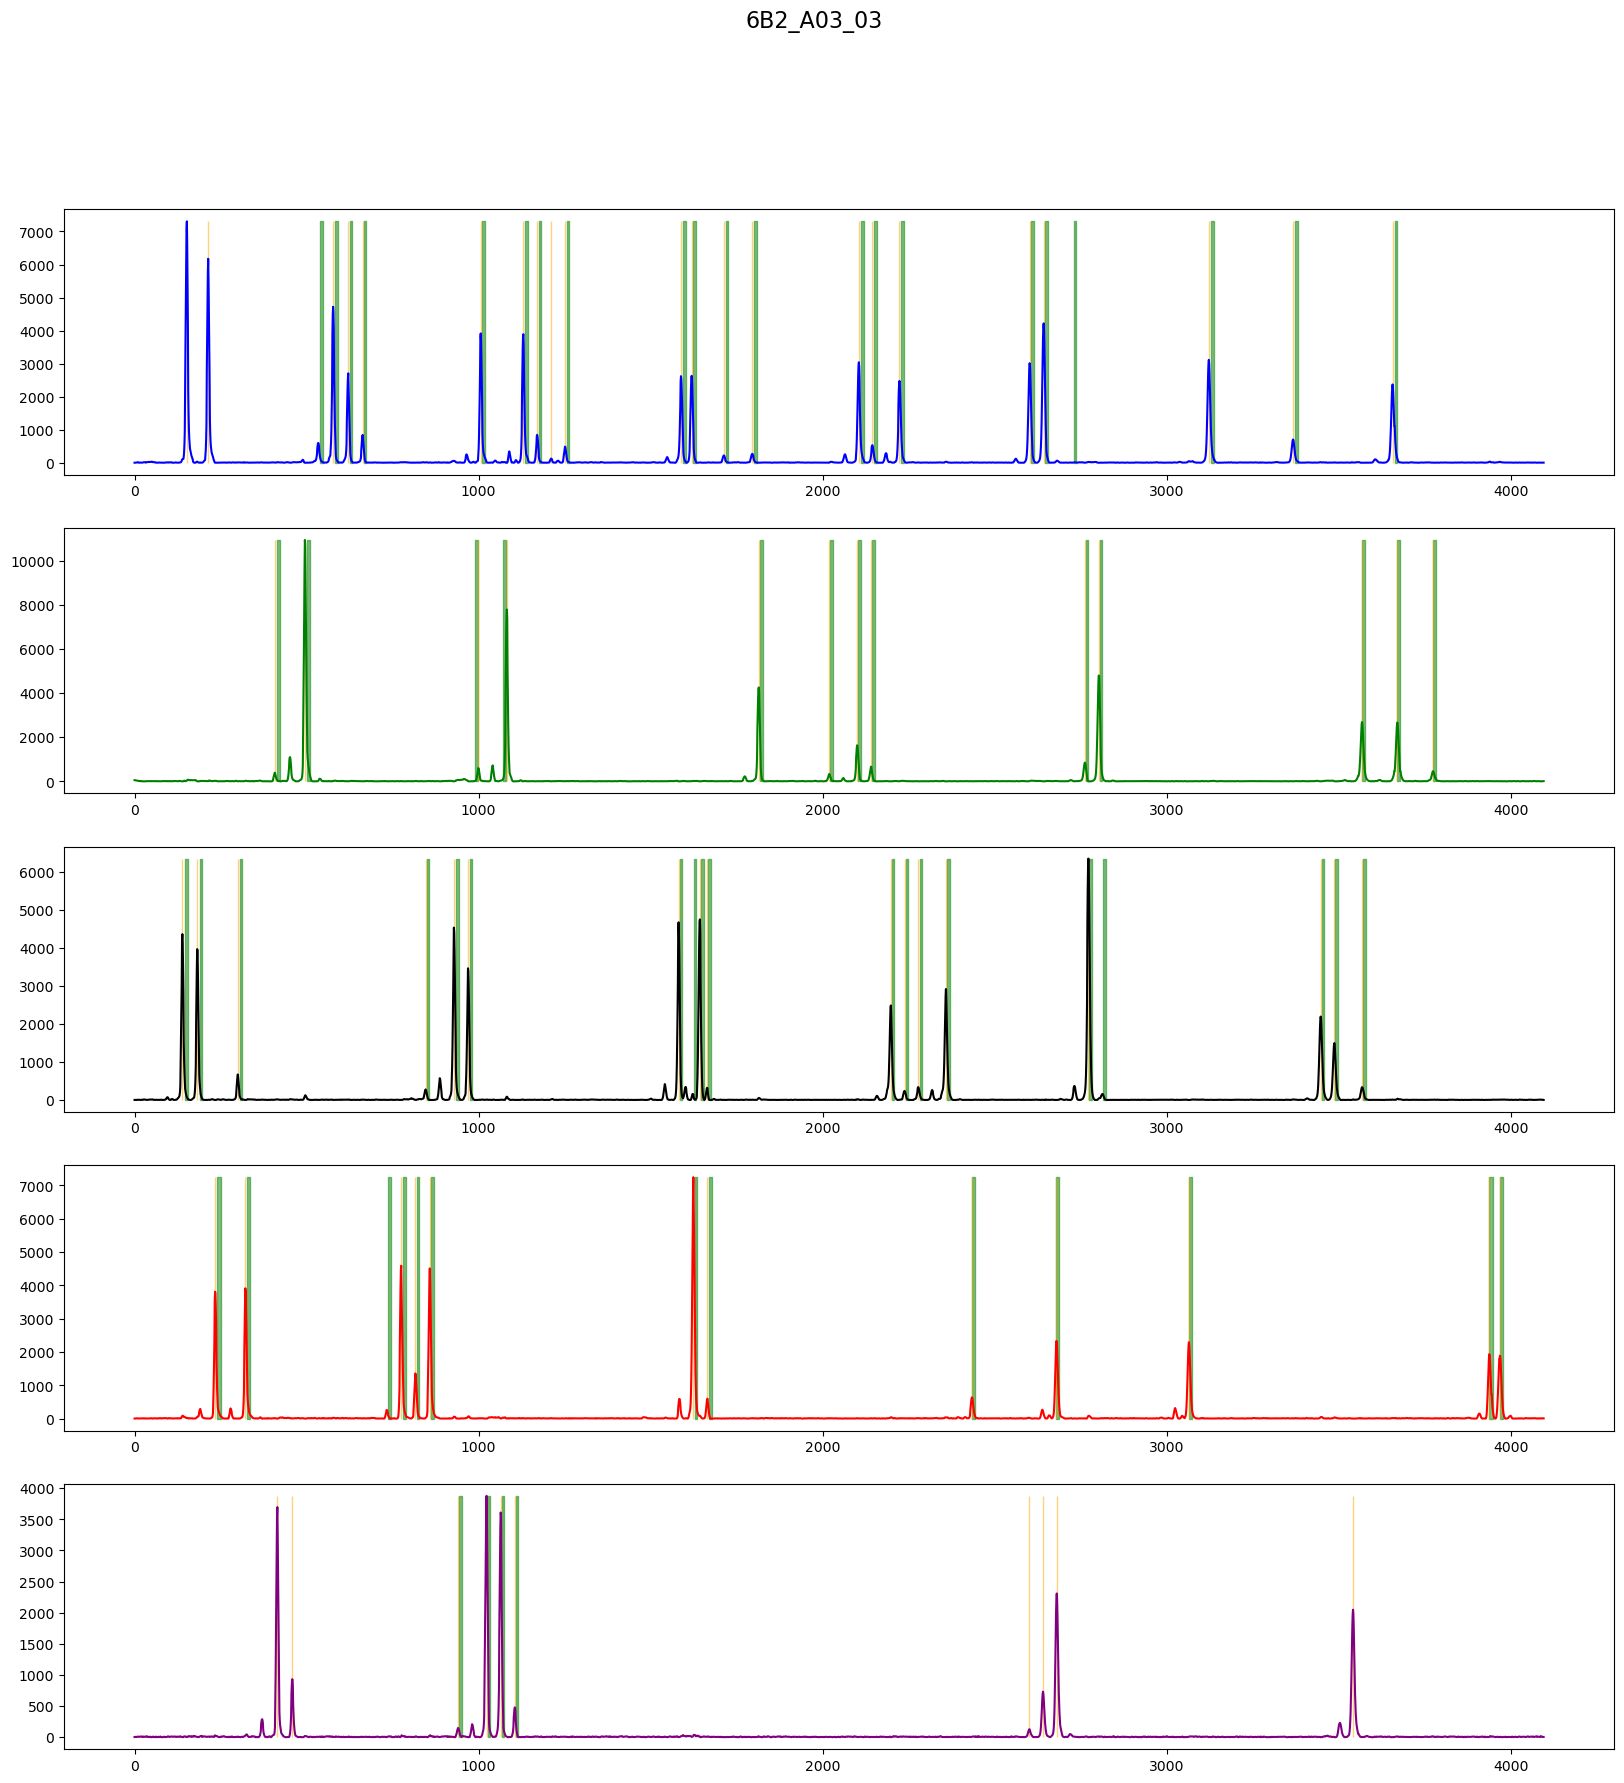

In [10]:
plot_profile(images[:1], predictions[:1], prediction_as_mask=True)

In [11]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall

# current issue: we are also retrieving ladder files, and other files not conforming to the standard
print('allele u-net f1: ', allele_f1_score(images, predictions))
print('allele u-net precision: ', allele_precision(images, predictions))
print('allele u-net recall: ', allele_recall(images, predictions))

allele u-net f1:  0.47164776517678453
allele u-net precision:  0.4636065573770492
allele u-net recall:  0.47997284453496264


## 30 mixtures:
* allele u-net f1:  0.47164776517678453
* allele u-net precision:  0.4636065573770492
* allele u-net recall:  0.47997284453496264

Looks like NFI ILS is absolutely funked